In [27]:
!pip install h2o

In [28]:
import h2o
from h2o.automl import H2OAutoML
import warnings
warnings.filterwarnings("ignore")
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,2 mins 12 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,4 months and 18 days
H2O_cluster_name:,H2O_from_python_unknownUser_g286qy
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,7.480 Gb
H2O_cluster_total_cores:,4
H2O_cluster_allowed_cores:,4
H2O_cluster_status:,"locked, healthy"


In [29]:
df=h2o.import_file("/kaggle/input/churn-dataset/Churn.csv")

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [30]:
df=df.drop(["CustomerId","RowNumber","Surname"])

In [31]:
df.head()

CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
619,France,Female,42,2,0,1,1,1,101349,1
608,Spain,Female,41,1,83807.9,1,0,1,112543,0
502,France,Female,42,8,159661,3,1,0,113932,1
699,France,Female,39,1,0,2,0,0,93826.6,0
850,Spain,Female,43,2,125511,1,1,1,79084.1,0
645,Spain,Male,44,8,113756,2,1,0,149757,1
822,France,Male,50,7,0,2,1,1,10062.8,0
376,Germany,Female,29,4,115047,4,1,0,119347,1
501,France,Male,44,4,142051,2,0,1,74940.5,0
684,France,Male,27,2,134604,1,1,1,71725.7,0


In [32]:
df.shape

(10000, 11)

In [33]:
df.as_data_frame().isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [34]:
train, test = df.split_frame(ratios=[0.7], seed=1234)

In [35]:
X=df.columns
y="Exited"
X.remove(y)

In [36]:
train[y] = train[y].asfactor()
test[y] = test[y].asfactor()


In [37]:
aml = H2OAutoML(max_models=15, seed=42,max_runtime_secs=3600,balance_classes=True,stopping_metric="AUC",sort_metric="AUC")
aml.train(x=X, y=y, training_frame=train)

AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


key,value
Stacking strategy,cross_validation
Number of base models (used / total),9/15
# GBM base models (used / total),4/6
# XGBoost base models (used / total),3/5
# DeepLearning base models (used / total),1/1
# DRF base models (used / total),1/2
# GLM base models (used / total),0/1
Metalearner algorithm,GLM
Metalearner fold assignment scheme,Random
Metalearner nfolds,5


In [38]:
lb = aml.leaderboard
lb.head(rows=lb.nrows)

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
StackedEnsemble_AllModels_1_AutoML_2_20250814_211950,0.86942,0.326622,0.707091,0.230235,0.314871,0.0991439
StackedEnsemble_BestOfFamily_1_AutoML_2_20250814_211950,0.869249,0.327446,0.704002,0.232294,0.315456,0.0995127
GBM_5_AutoML_2_20250814_211950,0.866257,0.342303,0.693224,0.231939,0.323577,0.104702
GBM_1_AutoML_2_20250814_211950,0.866246,0.34392,0.688901,0.224046,0.324788,0.105487
GBM_grid_1_AutoML_2_20250814_211950_model_1,0.865645,0.342427,0.6892,0.234781,0.323381,0.104576
XGBoost_grid_1_AutoML_2_20250814_211950_model_1,0.864477,0.332386,0.692507,0.233355,0.317798,0.100996
GBM_2_AutoML_2_20250814_211950,0.864146,0.34957,0.687593,0.244263,0.32761,0.107328
XGBoost_grid_1_AutoML_2_20250814_211950_model_2,0.863087,0.33433,0.693723,0.250686,0.319068,0.101804
XGBoost_3_AutoML_2_20250814_211950,0.860904,0.417848,0.695046,0.227349,0.36609,0.134022
GBM_3_AutoML_2_20250814_211950,0.86014,0.351888,0.677637,0.224033,0.329268,0.108418


In [39]:
aml.leader

key,value
Stacking strategy,cross_validation
Number of base models (used / total),9/15
# GBM base models (used / total),4/6
# XGBoost base models (used / total),3/5
# DeepLearning base models (used / total),1/1
# DRF base models (used / total),1/2
# GLM base models (used / total),0/1
Metalearner algorithm,GLM
Metalearner fold assignment scheme,Random
Metalearner nfolds,5


In [40]:
preds = aml.predict(test)
preds = aml.leader.predict(test)
preds.head()

stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


predict,p0,p1
0,0.707556,0.292444
0,0.955775,0.0442253
0,0.966102,0.033898
0,0.986982,0.0130184
0,0.9895,0.0105
1,0.47965,0.52035
0,0.986727,0.0132731
0,0.978279,0.0217208
0,0.98066,0.0193403
1,0.627065,0.372935


In [41]:
lb = h2o.automl.get_leaderboard(aml, extra_columns = "ALL")
lb

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
StackedEnsemble_AllModels_1_AutoML_2_20250814_211950,0.86942,0.326622,0.707091,0.230235,0.314871,0.0991439,6584,0.03199,StackedEnsemble
StackedEnsemble_BestOfFamily_1_AutoML_2_20250814_211950,0.869249,0.327446,0.704002,0.232294,0.315456,0.0995127,6574,0.018997,StackedEnsemble
GBM_5_AutoML_2_20250814_211950,0.866257,0.342303,0.693224,0.231939,0.323577,0.104702,414,0.007085,GBM
GBM_1_AutoML_2_20250814_211950,0.866246,0.34392,0.688901,0.224046,0.324788,0.105487,489,0.008799,GBM
GBM_grid_1_AutoML_2_20250814_211950_model_1,0.865645,0.342427,0.6892,0.234781,0.323381,0.104576,336,0.006981,GBM
XGBoost_grid_1_AutoML_2_20250814_211950_model_1,0.864477,0.332386,0.692507,0.233355,0.317798,0.100996,666,0.004232,XGBoost
GBM_2_AutoML_2_20250814_211950,0.864146,0.34957,0.687593,0.244263,0.32761,0.107328,304,0.006847,GBM
XGBoost_grid_1_AutoML_2_20250814_211950_model_2,0.863087,0.33433,0.693723,0.250686,0.319068,0.101804,683,0.004066,XGBoost
XGBoost_3_AutoML_2_20250814_211950,0.860904,0.417848,0.695046,0.227349,0.36609,0.134022,465,0.003669,XGBoost
GBM_3_AutoML_2_20250814_211950,0.86014,0.351888,0.677637,0.224033,0.329268,0.108418,410,0.006958,GBM


In [42]:
first_model_id = lb[0, "model_id"]
print(first_model_id)

StackedEnsemble_AllModels_1_AutoML_2_20250814_211950


In [43]:
perf = aml.leader.model_performance(test_data=test)


# Other metrics
print("Accuracy:", perf.accuracy()[0][1])
print("AUC:", perf.auc())
print("F1 Score:", perf.F1()[0][1])
print("Precision:", perf.precision()[0][1])
print("Recall:", perf.recall()[0][1])

Accuracy: 0.8610830810628994
AUC: 0.8579710096118225
F1 Score: 0.6439100077579518
Precision: 1.0
Recall: 1.0


In [44]:
m = h2o.get_model(first_model_id)
m.params.keys()

dict_keys(['model_id', 'training_frame', 'response_column', 'validation_frame', 'blending_frame', 'base_models', 'metalearner_algorithm', 'metalearner_nfolds', 'metalearner_fold_assignment', 'metalearner_fold_column', 'metalearner_params', 'metalearner_transform', 'max_runtime_secs', 'weights_column', 'offset_column', 'custom_metric_func', 'seed', 'score_training_samples', 'keep_levelone_frame', 'export_checkpoints_dir', 'auc_type', 'gainslift_bins'])

In [45]:
# Get AutoML event log
log = aml.event_log
log.show()

timestamp,level,stage,message,name,value
21:19:50.861,INFO,Workflow,Project: AutoML_2_20250814_211950,,
21:19:50.861,INFO,Validation,5-fold cross-validation will be used.,,
21:19:50.861,INFO,Validation,Setting stopping tolerance adaptively based on the training frame: 0.011929301725041393,,
21:19:50.861,INFO,Validation,Build control seed: 42,,
21:19:50.862,INFO,DataImport,training frame: Frame key: AutoML_2_20250814_211950_training_py_19_sid_8a06 cols: 11 rows: 7027 chunks: 16 size: 135854 checksum: 6160313924796466520,,
21:19:50.862,INFO,DataImport,validation frame: NULL,,
21:19:50.862,INFO,DataImport,leaderboard frame: NULL,,
21:19:50.862,INFO,DataImport,blending frame: NULL,,
21:19:50.862,INFO,DataImport,response column: Exited,,
21:19:50.862,INFO,DataImport,fold column: null,,


In [46]:
info = aml.training_info
info.keys()

dict_keys(['creation_epoch', 'start_epoch', 'start_XGBoost_def_2', 'start_GLM_def_1', 'start_GBM_def_5', 'start_XGBoost_def_1', 'start_DRF_def_1', 'start_GBM_def_2', 'start_GBM_def_3', 'start_GBM_def_4', 'start_XGBoost_def_3', 'start_DRF_XRT', 'start_GBM_def_1', 'start_DeepLearning_def_1', 'start_XGBoost_grid_1', 'start_GBM_grid_1', 'start_StackedEnsemble_best_of_family_xglm', 'start_StackedEnsemble_all_xglm', 'stop_epoch', 'duration_secs'])

In [47]:
best_model = aml.leader
model_path = h2o.save_model(model=best_model, path="models/", force=True)
print("Best model saved to:", model_path)

Best model saved to: /kaggle/working/models/StackedEnsemble_AllModels_1_AutoML_2_20250814_211950


In [48]:
perf = aml.leader.model_performance(test_data=test)
perf.confusion_matrix()


,0,1,Error,Rate
0,2099.0,239.0,0.1022,(239.0/2338.0)
1,220.0,415.0,0.3465,(220.0/635.0)
Total,2319.0,654.0,0.1544,(459.0/2973.0)


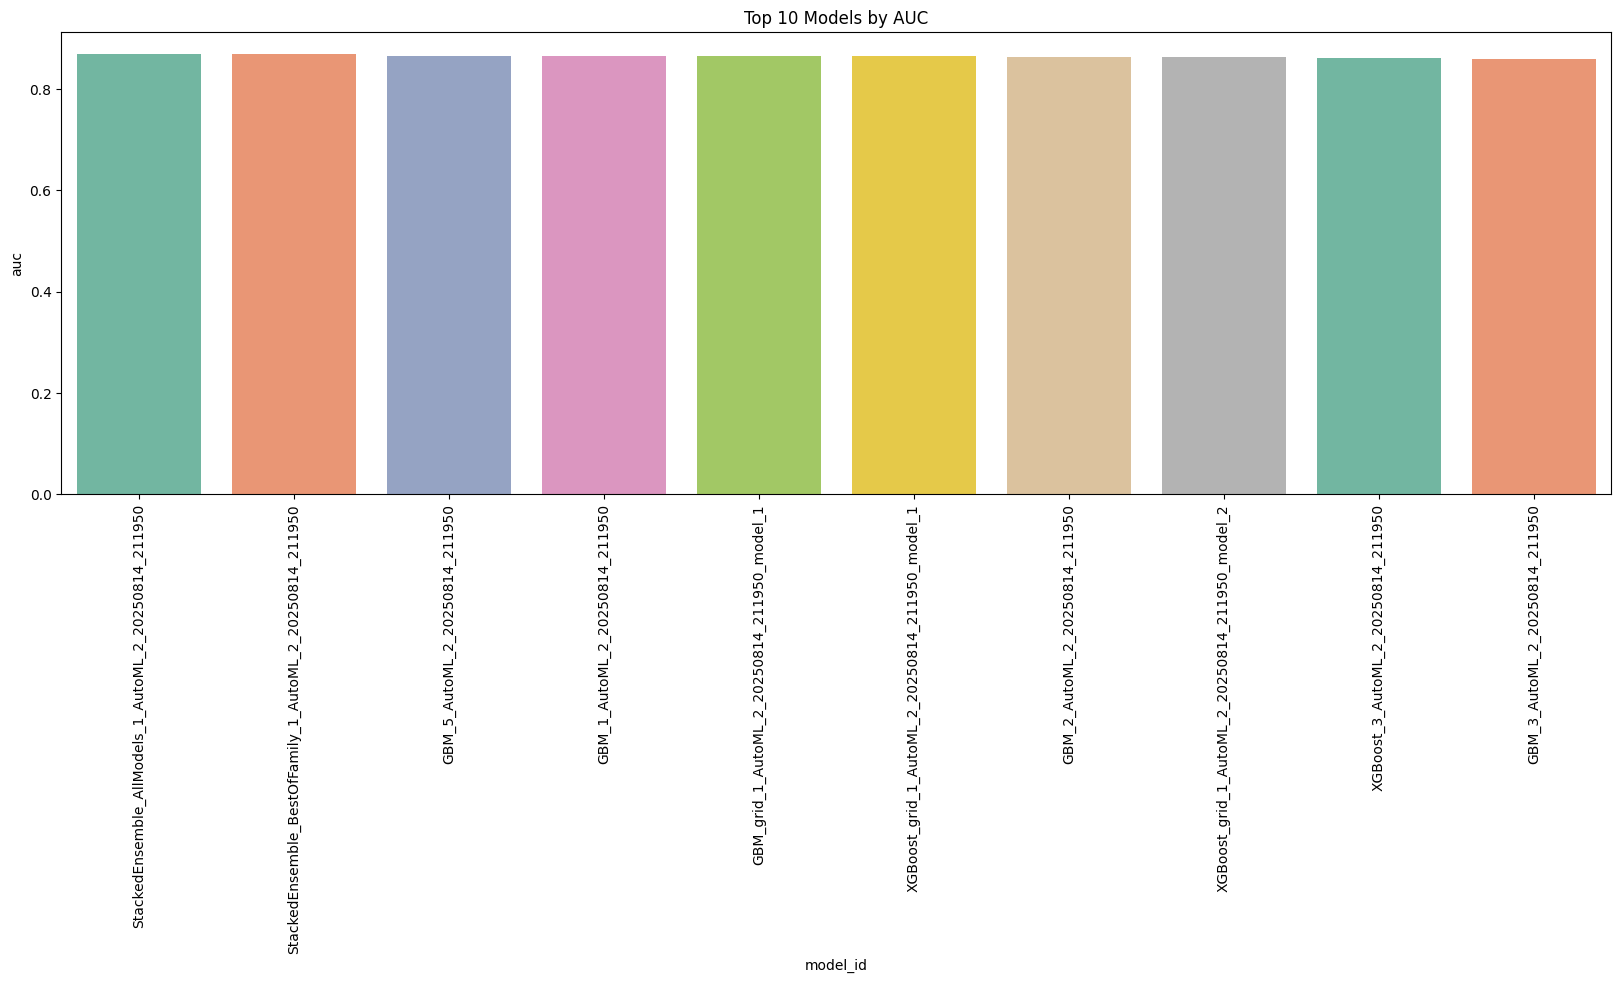

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
lb = aml.leaderboard.as_data_frame()
top10 = lb.head(10)
plt.figure(figsize=(20, 6))
sns.barplot(x="model_id", y="auc", data=top10,palette="Set2")
plt.xticks(rotation=90)
plt.title("Top 10 Models by AUC")
plt.show()

In [50]:
import numpy as np
preds = aml.leader.predict(test)
preds_df = preds.as_data_frame()
test_df = test.as_data_frame()
y_true = test_df[y]
y_pred = preds_df['predict']
is_binary = len(np.unique(y_true)) == 2
if is_binary:
    y_pred_prob = preds_df['p1']
else:
    prob_cols = [col for col in preds_df.columns if col.startswith('p')]
    y_pred_prob = preds_df[prob_cols].values

lb_df = aml.leaderboard.as_data_frame()

stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


In [51]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, PrecisionRecallDisplay
from sklearn.calibration import calibration_curve
import shap


<Figure size 1000x600 with 0 Axes>

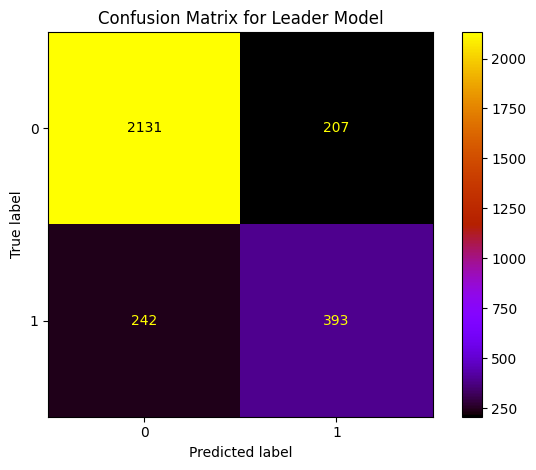

In [52]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_true))
plt.figure(figsize=(10, 6))
disp.plot(cmap='gnuplot')
plt.title('Confusion Matrix for Leader Model')
plt.tight_layout()
plt.show()

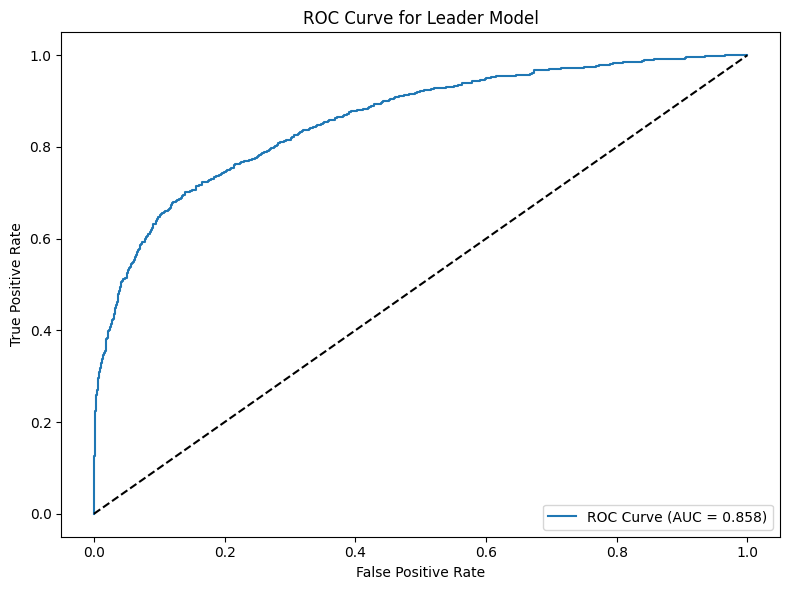

In [53]:
plt.figure(figsize=(8, 6))
if is_binary:
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob, pos_label=1)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
else:
    for i, class_label in enumerate(np.unique(y_true)):
        fpr, tpr, _ = roc_curve(y_true == class_label, y_pred_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {class_label} (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Leader Model')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


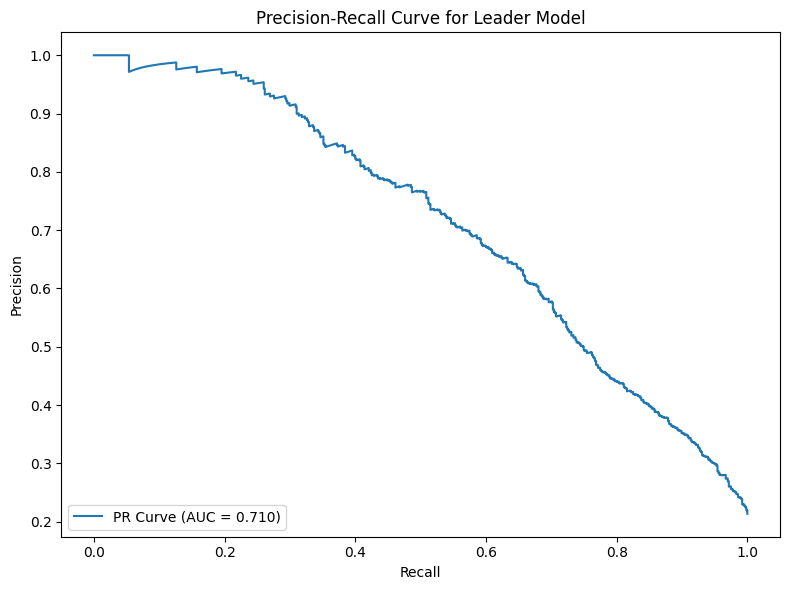

In [54]:
plt.figure(figsize=(8, 6))
if is_binary:
    precision, recall, _ = precision_recall_curve(y_true, y_pred_prob, pos_label=1)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.3f})')
else:
    for i, class_label in enumerate(np.unique(y_true)):
        precision, recall, _ = precision_recall_curve(y_true == class_label, y_pred_prob[:, i])
        pr_auc = auc(recall, precision)
        plt.plot(recall, precision, label=f'Class {class_label} (AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Leader Model')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

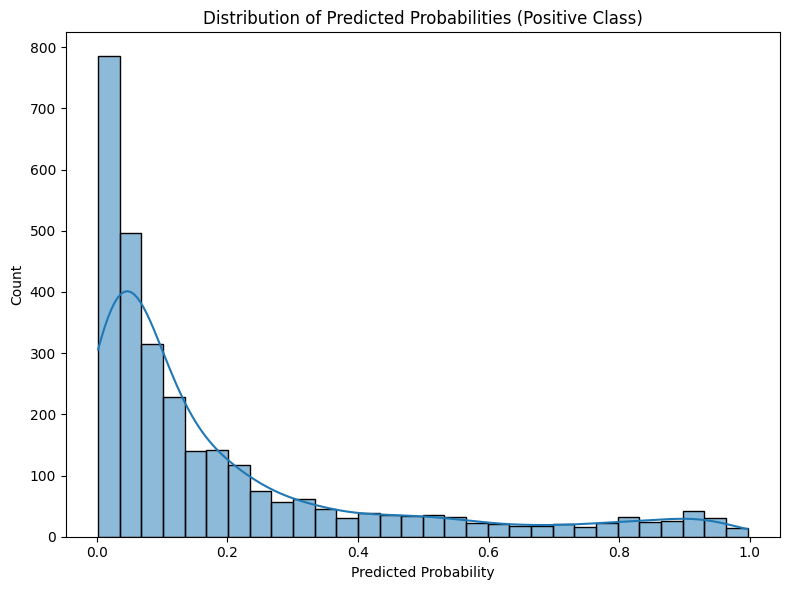

In [55]:
plt.figure(figsize=(8, 6))
if is_binary:
    sns.histplot(y_pred_prob, kde=True, bins=30)
    plt.title('Distribution of Predicted Probabilities (Positive Class)')
    plt.xlabel('Predicted Probability')
else:
    for i, class_label in enumerate(np.unique(y_true)):
        sns.histplot(y_pred_prob[:, i], kde=True, bins=30, label=f'Class {class_label}', alpha=0.5)
    plt.legend()
plt.ylabel('Count')
plt.tight_layout()
plt.show()

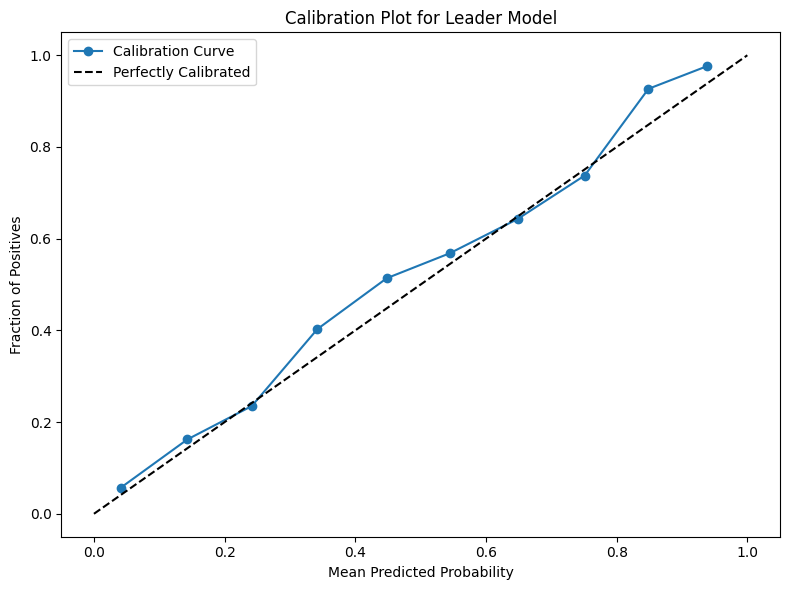

In [56]:
if is_binary:
    prob_true, prob_pred = calibration_curve(y_true, y_pred_prob, n_bins=10)
    plt.figure(figsize=(8, 6))
    plt.plot(prob_pred, prob_true, marker='o', label='Calibration Curve')
    plt.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.title('Calibration Plot for Leader Model')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [57]:
dir(aml)          # List all attributes and methods of AutoML object
dir(aml.leader)   # List all attributes and methods of the leader model


['F0point5',
 'F1',
 'F2',
 '_H2OEstimator__default_params',
 '_ModelBase__generate_partial_plots',
 '_ModelBase__generate_user_splits',
 '_ModelBase__grab_values',
 '_ModelBase__plot_1d_pdp',
 '_ModelBase__plot_1d_pdp_multinomial',
 '_ModelBase__plot_2d_pdp',
 '_ModelBase__pred_for_3d',
 '_ModelBase__set_axs_1d',
 '_ModelBase__set_axs_1d_multinomial',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__unicode__',
 '__weakref__',
 '_bc',
 '_bci',
 '_check_and_save_parm',
 '_check_targets',
 '_default_param_value',
 '_delegate_to_metrics',
 '_end_time',
 '_estimator_type',
 '_extract_scoring_history',
 '_fillMultinomialDict',
 '_future',
 '_get_metrics'